<a href="https://colab.research.google.com/github/ShauryaGupta18/Projects/blob/main/valuepie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Monte Carlo Simulation for π Estimation & Convergence Analysis

Built a Monte Carlo simulation to approximate the value of π by randomly sampling points within a unit square and estimating the ratio that falls inside a quarter circle. Analyzed how estimation accuracy evolves with increasing sample size by computing error metrics across a range of
𝑛
n.

Observed that while smaller sample sizes can occasionally produce highly accurate estimates due to randomness, they exhibit high variance and are unreliable. Demonstrated that increasing the number of samples reduces variance and leads to more stable and consistent estimates, aligning with the Law of Large Numbers.

Applied linear regression to smooth noisy error trends and highlight the overall convergence pattern, showing that error decreases as sample size increases. The project emphasizes the trade-off between variance and reliability in stochastic simulations.

In [16]:
#Creating the dart board

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import random
import math

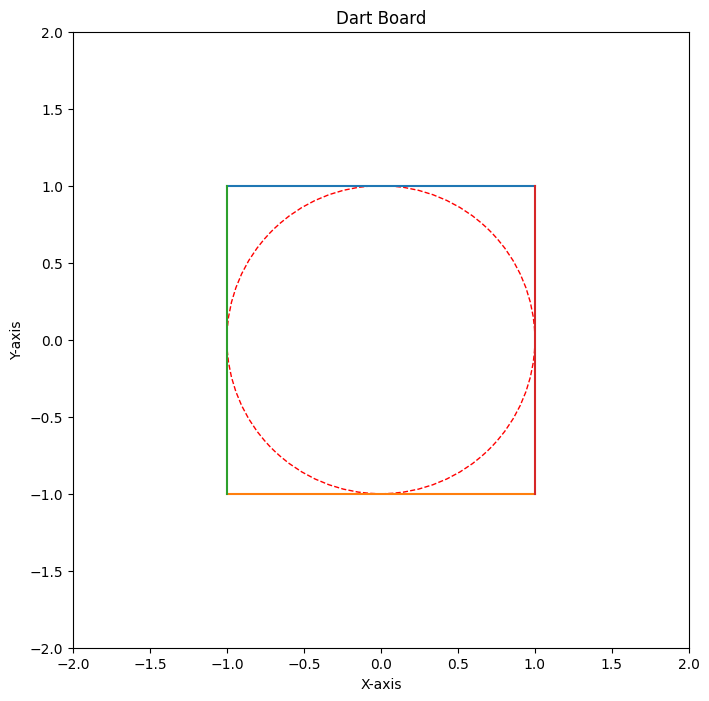

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(x, 0 * x + 1)
ax.plot(x, 0* x - 1)
ax.plot(np.full_like(y, -1), y)
ax.plot(np.full_like(y, 1), y)
circle_center = (0, 0)  # Center of the circle
circle_radius = 1      # Radius of the circle

circle = plt.Circle(circle_center, circle_radius, color='red', fill=False, linestyle='--', label='Circle (radius=5)')
ax.add_artist(circle)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title('Dart Board')

# Set limits to ensure the circle is visible
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Set aspect ratio to be equal for a true circle
ax.set_aspect('equal', adjustable='box')

# Display the plot
plt.show()



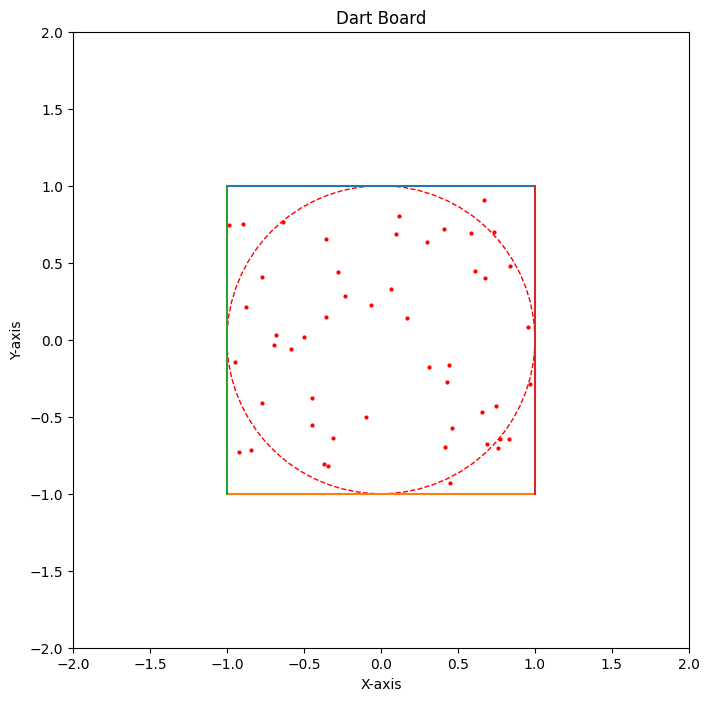

3.12


In [23]:
#Create random points
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(8, 8))

# Define the x values
x = np.linspace(-1, 1, 400)
y = np.linspace(-1,1,400)

n=50
no=0

for _ in range(n):
  a = np.random.uniform(-1.0, 1.0)
  b = np.random.uniform(-1.0, 1.0)
  plt.plot(a, b, 'ro',markersize=2)
  if((a**2+b**2)<=1):
    no=no+1

# Plot four lines
ax.plot(x, 0 * x + 1)
ax.plot(x, 0* x - 1)
ax.plot(np.full_like(y, -1), y)
ax.plot(np.full_like(y, 1), y)

# Add a circle
circle_center = (0, 0)  # Center of the circle
circle_radius = 1      # Radius of the circle

circle = plt.Circle(circle_center, circle_radius, color='red', fill=False, linestyle='--', label='Circle (radius=5)')
ax.add_artist(circle)

# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title('Dart Board')

# Set limits to ensure the circle is visible
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Set aspect ratio to be equal for a true circle
ax.set_aspect('equal', adjustable='box')

# Display the plot
plt.show()

print(no/n*4)

In [19]:
#Creating a function that gives value of pie
def estimatepie(n):
  no=0
  for _ in range(n):
    a=np.random.uniform(-1.0,1.0)
    b=np.random.uniform(-1.0,1.0)
    if((a**2 + b**2)<=1):
      no=no+1
  return (no/n*4)

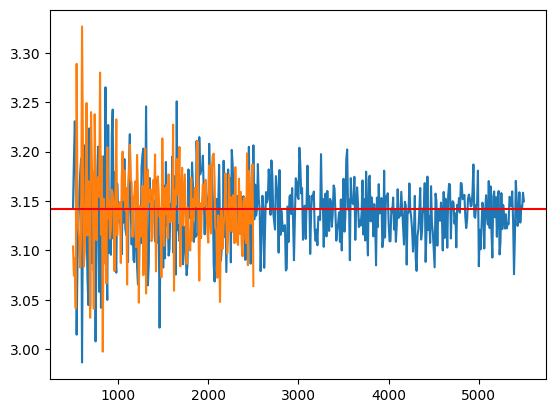

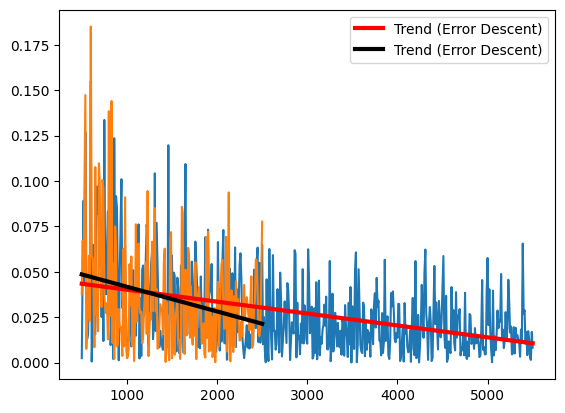

Error percentage at the last according to our best fit line:  0.9636103230533197


In [34]:
#Checking for different values of n
k=5000
t=2000
v=[]
e=[]
v1=[]
v2=[]
x_axis=[]
x1_axis=[]
for i in range(500,501+k,10):
  ex=estimatepie(i)
  v.append(ex)
  e.append(abs(ex - math.pi))
  x_axis.append(i)

for i in range(500,501+t,10):
  ex=estimatepie(i)
  v1.append(ex)
  v2.append(abs(ex - math.pi))
  x1_axis.append(i)

plt.plot(x_axis,v)
plt.plot(x1_axis,v1)
plt.axhline(y=math.pi, color='r', linestyle='-')
plt.show()
plt.plot(x_axis,e)
plt.plot(x1_axis,v2)


m, b = np.polyfit(x_axis, e, 1)

trend_line = m * np.array(x_axis) + b

m1,b1 = np.polyfit(x1_axis,v2,1)
trend_line1 = m1 * np.array(x1_axis) + b1
plt.plot(x_axis, trend_line, color='red', linewidth=3, label='Trend (Error Descent)')
plt.plot(x1_axis, trend_line1, color='black', linewidth=3, label='Trend (Error Descent)')
plt.legend()
plt.show()

red_last = x1_axis[-1]
last_val = m * red_last + b
print("Error percentage at the last according to our best fit line: " ,(last_val / math.pi )*100)

